## check subcloud layer top mass flux!

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.dates as mdates
import numpy as np

import intake

import sys
# sys.path.append("/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/") 

# sys.path.append("/work/mh1498/m301248/TCO_data/BCO_observational/mass_fluxes_profiles/yk22_mass_fluxes.py")
# import yk22_mass_fluxes

import metpy

# import meteo


import pandas as pd
from IPython.display import display, HTML


## working local
local_path = {
              "joanne4": "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/dropsondes_34/EUREC4A_JOANNE_Dropsonde-RD41_Level_4_v2.0.0.nc",
              "joanne3": "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/dropsondes_34/EUREC4A_JOANNE_Dropsonde-RD41_Level_3_v2.0.0.nc",
              "beach4": "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/dropsondes_34/ORCESTRA_BEACH_level_4.nc",
              "beach3":  "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/dropsondes_34/ORCESTRA_BEACH_level_3.nc"
              }

In [2]:
## constants I always need
Lv = 2.5e6  # J/kg
cp = 1004.7 # J/kg K

Rd = 287.   # J / kg K
g = 9.81    # m / s2

### open BEACH

In [48]:
## local access
beach4  = xr.open_dataset(local_path["beach4"])  # level 4
beach3 = xr.open_dataset(local_path["beach3"])  # level 3


beach4 = beach4.swap_dims({"sonde": "sonde_id"})
beach3 = beach3.swap_dims({"sonde": "sonde_id"})
common = np.intersect1d(beach3.sonde_id, beach4.sonde_id)

beach3 = beach3.sel(sonde_id=common)
beach4 = beach4.sel(sonde_id=common)

beach3 = beach3.sortby(beach3.launch_time)
beach4 = beach4.sortby(beach4.circle_time)


## assign labels to define which circle each sonde belongs to

circle_labels = np.repeat(
    beach4.circle.values,
    beach4.sondes_per_circle.values
)


beach3 = beach3.assign_coords(
    circle=("sonde_id", circle_labels)
)

beach4 = beach4.assign_coords(
    circle=("sonde_id", circle_labels)
)

circle_da = xr.DataArray(
    circle_labels,
    dims="sonde_id",
    coords={"sonde_id": beach3.sonde_id},
    name="circle"
)

In [49]:
west = (beach4.circle_lon < -40)
beach4w = beach4.sel(altitude=slice(0,7000)).where(west, drop=True)


west = (beach3.launch_lon < -40)
beach3w = beach3.sel(altitude=slice(0,7000)).where(west, drop=True)

In [52]:
rho_orw = beach3w.p / (Rd * beach3w.ta*(1 + 0.61*beach3w.q))
# rho_orw = rho_orw.where(west, drop=True)
circle_rho_orw = rho_orw.groupby("circle").mean("sonde_id")

### open JOANNE

In [53]:
## local access
joanne4  = xr.open_dataset(local_path["joanne4"])  # level 4
joanne3 = xr.open_dataset(local_path["joanne3"])  # level 3


halo = joanne4.platform_id == "HALO"
joanne4 = joanne4.sel(alt=slice(0,7000)).where(halo, drop=True)

halo = joanne3.platform_id == "HALO"
joanne3 = joanne3.sel(alt=slice(0,7000)).where(halo, drop=True)

In [65]:
rho_eu = joanne4.p / (Rd * joanne4.ta*(1 + 0.61*joanne4.q))

In [54]:
joanne4

<xarray.Dataset> Size: 6MB
Dimensions:          (circle: 71, alt: 701, sounding: 13)
Coordinates:
  * circle           (circle) int64 568B 14 15 16 17 18 19 ... 79 80 81 82 83 84
    circle_lon       (circle) float32 284B -57.86 -57.7 -57.71 ... -57.67 -57.65
    circle_lat       (circle) float32 284B 13.27 13.27 13.28 ... 13.33 13.33
    circle_time      (circle) datetime64[ns] 568B 2020-01-19T17:53:57.800000 ...
    segment_id       (circle) <U12 3kB 'HALO-0119_c1' ... 'HALO-0215_c6'
  * alt              (alt) int16 1kB 0 10 20 30 40 ... 6960 6970 6980 6990 7000
  * sounding         (sounding) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
Data variables: (12/36)
    platform_id      (circle) object 568B 'HALO' 'HALO' 'HALO' ... 'HALO' 'HALO'
    flight_altitude  (circle) float32 284B 1.026e+04 1.029e+04 ... 1.119e+04
    circle_diameter  (circle) float32 284B 1.867e+05 2.225e+05 ... 2.236e+05
    u                (circle, alt) float32 199kB nan -8.829 ... 10.53 10.54
    dudx             (circle, alt) float32 199kB nan 8.21e-06 ... 1.218e-05
    dudy             (circle, alt) float32 199kB nan 6.836e-06 ... -1.307e-05
    ...               ...
    se_dtadx         (circle, alt) float32 199kB nan -0.0 ... 1.407e-06 1.39e-06
    se_dtady         (circle, alt) float32 199kB nan -0.0 ... 1.573e-06
    se_D             (circle, alt) float32 199kB nan 6.747e-06 ... 1.161e-05
    se_vor           (circle, alt) float32 199kB nan 6.725e-06 ... 1.07e-05
    se_W             (circle, alt) float32 199kB 0.0 6.747e-06 ... 0.007306
    omega            (circle, alt) float32 199kB nan 0.002026 ... -0.007611
Attributes: (12/16)
    title:                   EUREC4A JOANNE Level-4
    doi:                     10.25326/246
    created with:            run_joanne.py doi:10.5281/zenodo.5521192
    Conventions:             CF-1.8
    campaign_id:             EUREC4A
    project_id:              JOANNE
    ...                      ...
    JOANNE_version:          2.0.0
    author:                  Geet George
    author_email:            geet.george@mpimet.mpg.de
    featureType:             trajectory
    reference:               George et al., JOANNE : Joint dropsonde Observat...
    creation_time:           2021-09-22 15:58:46.773760 UTC

let's see the w profiles

/Users/alessandrostorer/.local/share/mamba/envs/env_hacka/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


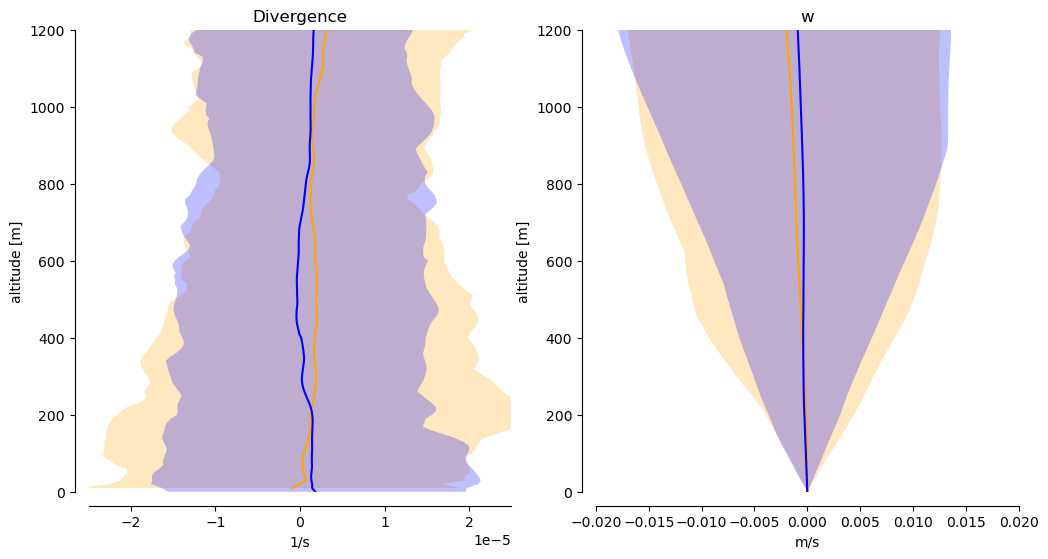

In [67]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax = ax.flatten()

def plot_mean_band(da, ydim, ax, color, q=(0.025, 0.975), alpha=0.25):
    mean = da.mean(dim="circle")
    lo = da.quantile(q[0], dim="circle")
    hi = da.quantile(q[1], dim="circle")
    y = da[ydim].values

    mean.plot.line(ax=ax, y=ydim, color=color)
    ax.fill_betweenx(y, lo.values, hi.values, color=color, alpha=alpha, linewidth=0)


div_eu = joanne4.D
w_eu = joanne4.W
div_orw = beach4w.div
w_orw = beach4w.omega / (-circle_rho_orw * g)

plot_mean_band(div_eu,  "alt",      ax[0], "orange")
plot_mean_band(w_eu,    "alt",      ax[1], "orange")
plot_mean_band(div_orw, "altitude", ax[0], "blue")
plot_mean_band(w_orw,   "altitude", ax[1], "blue")


ax[0].set_title("Divergence")
ax[0].set_xlabel("1/s")

ax[1].set_title("w")
ax[1].set_xlabel("m/s")


ax[0].set_xlim([-2.5e-5, 2.5e-5])
ax[1].set_xlim([-2e-2, 2e-2])


for x in ax:
    x.set_ylim([0,1200])
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

    for spine in ["left", 'bottom']:
        x.spines[spine].set_position(("outward", 10))

/Users/alessandrostorer/.local/share/mamba/envs/env_hacka/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/alessandrostorer/.local/share/mamba/envs/env_hacka/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


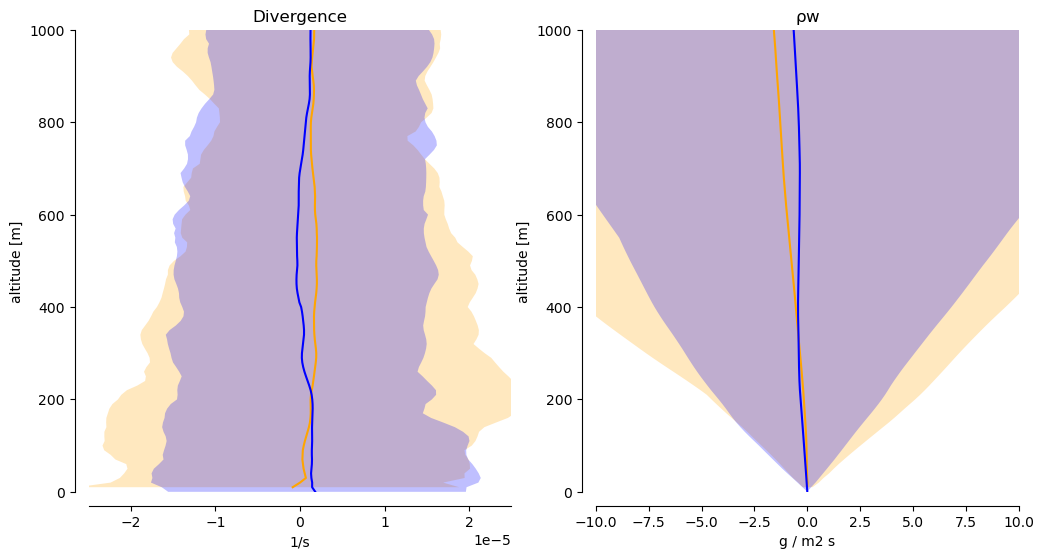

In [78]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax = ax.flatten()

def plot_mean_band(da, ydim, ax, color, q=(0.025, 0.975), alpha=0.25):
    mean = da.mean(dim="circle")
    lo = da.quantile(q[0], dim="circle")
    hi = da.quantile(q[1], dim="circle")
    y = da[ydim].values

    mean.plot.line(ax=ax, y=ydim, color=color)
    ax.fill_betweenx(y, lo.values, hi.values, color=color, alpha=alpha, linewidth=0)


div_eu = joanne4.D
rhow_eu = joanne4.W * rho_eu
div_orw = beach4w.div
rhow_orw = beach4w.omega / (- g)

plot_mean_band(div_eu,  "alt",      ax[0], "orange")
plot_mean_band(1e3*rhow_eu,    "alt",      ax[1], "orange")
plot_mean_band(div_orw, "altitude", ax[0], "blue")
plot_mean_band(1e3*rhow_orw,   "altitude", ax[1], "blue")


ax[0].set_title("Divergence")
ax[0].set_xlabel("1/s")

ax[1].set_title(r"$\rm \rho w$")
ax[1].set_xlabel("g / m2 s")


ax[0].set_xlim([-2.5e-5, 2.5e-5])
ax[1].set_xlim([-10, 10])

for x in ax:
    x.set_ylim([0,1000])
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

    for spine in ["left", 'bottom']:
        x.spines[spine].set_position(("outward", 10))

(array([0.00840493, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.01680987, 0.01680987, 0.05883454, 0.06723948,
        0.07564441, 0.05042964, 0.04202464, 0.02521482, 0.01680986]),
 array([-27.68893051, -25.044981  , -22.40103149, -19.75708389,
        -17.11313248, -14.46918392, -11.82523537,  -9.18128586,
         -6.53733635,  -3.89338684,  -1.24943733,   1.39451218,
          4.03845978,   6.68241119,   9.3263588 ,  11.97031021]),
 [<matplotlib.patches.Polygon at 0x3c4d78bc0>])

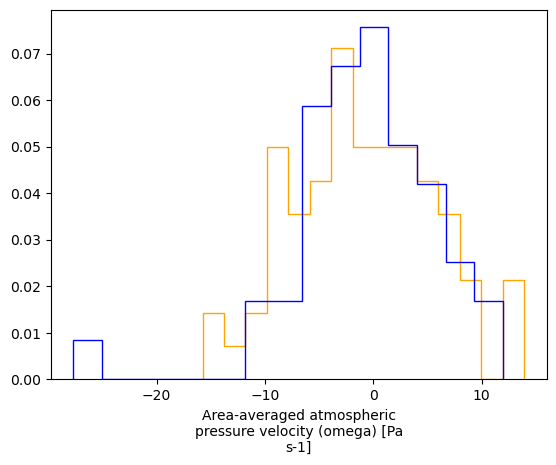

In [73]:
rhow_eu = joanne4.W * rho_eu
rhow_orw = beach4w.omega / (- g)

(1e3*rhow_eu).sel(alt=slice(500, 700)).mean(dim="alt").plot.hist(bins=15, density=True, histtype="step", color="orange")
(1e3*rhow_orw).sel(altitude=slice(500, 700)).mean(dim="altitude").plot.hist(bins=15, density=True, histtype="step", color="blue")